In [4]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

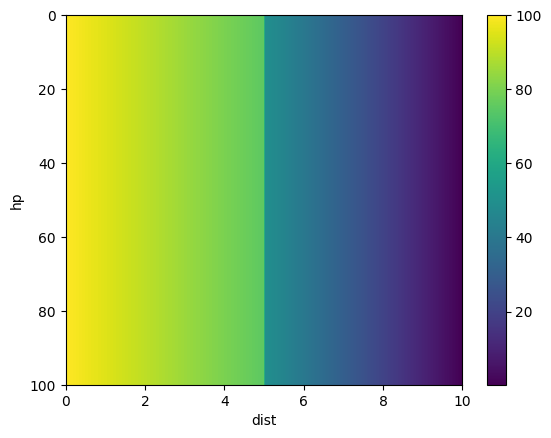

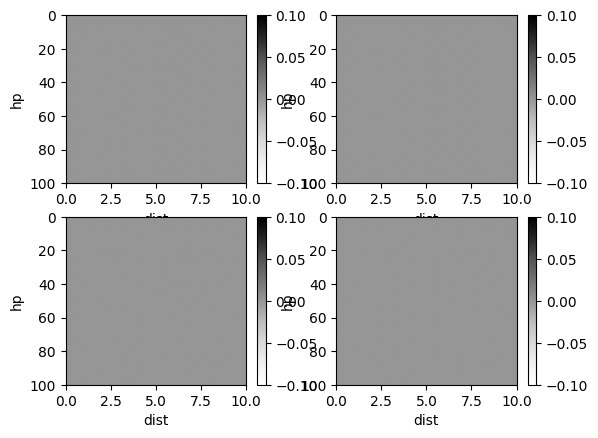

In [5]:

def flee(hp, dist):
    return (100 - hp) * 5 - 50 * dist  + np.random.randn() * 0

def attack(hp, dist):
    return 100 - 10 * dist  + np.random.randn() * 0

def patchup(hp, dist):
    return 140 - hp  + np.random.randn() * 0

def patrol(hp, dist):
    return 50  + np.random.randn() * 0 

def explorer_utility(hp, dist_to_base, dist_to_enemy, allies_nearby):
    if dist_to_enemy < 3 and dist_to_base < 5:
        return 100 - 10 * dist_to_enemy
    elif dist_to_enemy < 5 and dist_to_base >= 5:
        return 100 - 10 * dist_to_base
    elif allies_nearby == 0 and dist_to_base > 5:
        return 100 - dist_to_base
    else:
        return 50

HP = np.arange(0, 100, 0.25)
DIST = np.arange(0, 10, 0.025)
img = np.zeros((HP.shape[0], DIST.shape[0]))
ht = np.zeros((4, HP.shape[0], DIST.shape[0]))
# TODO: Vectorize
for x, hp in enumerate(HP):
    for y, ds in enumerate(DIST):
        # utility = np.array([flee(hp, ds), attack(hp, ds), patchup(hp, ds), patrol(hp, ds)])
        # for i in range(utility.shape[0]):
        #     ht[i][x][y] = utility[i]
        # img[x][y] = np.argmax(utility)
        # Расчет утилитарного значения
        enemy_dist = ds / 2
        allies = 1 if ds < 3 else 0
        utility = explorer_utility(hp, ds, enemy_dist, allies)
        img[x][y] = utility


fig, ax = plt.subplots()
im = ax.imshow(img, extent=[0, 10, 100, 0])
ax.set_aspect('auto')
ax.set_xlabel("dist")
ax.set_ylabel("hp")


plt.colorbar(im)

fig, ax = plt.subplots(2, 2)
for i in range(4):
    im = ax[i %2, i // 2].imshow(ht[i], extent=[0, 10, 100, 0], cmap='Greys')
    ax[i %2, i // 2].set_aspect('auto')
    ax[i %2, i // 2].set_xlabel("dist")
    ax[i %2, i // 2].set_ylabel("hp")
    plt.colorbar(im)

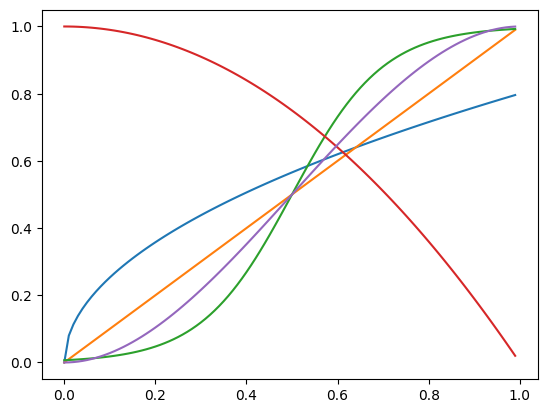

In [6]:
X = np.arange(0, 1, 0.01)
plt.plot(X, (X ** 0.5) * 0.8)
plt.plot(X, X)
plt.plot(X, 1 / (1 + np.exp(-(X * 10 - 5))))
plt.plot(X, 1 - X ** 2)
plt.plot(X, -2 * X ** 3 + 3 * X ** 2)